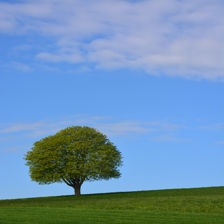

In [2]:
import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

torch.manual_seed(0)

# Config
img_path = "../data/p2ch9/tree.jpg"
img_size = 224                        # ViT-B default
patch_size = 16                       # ViT-B default

# Load and resize image (HxW must be divisible by patch_size)
img = Image.open(img_path).convert("RGB").resize((img_size, img_size))
img

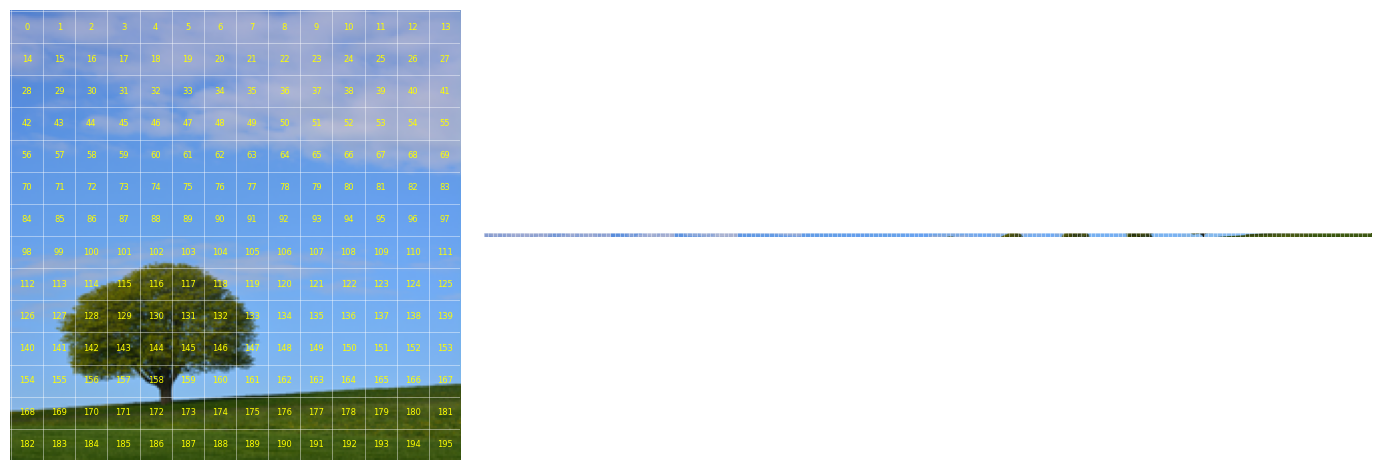

In [ ]:
# To tensor (C,H,W), batch it
to_tensor = transforms.ToTensor()
x = to_tensor(img).unsqueeze(0)  # [1,3,H,W]
B, C, H, W = x.shape
assert H % patch_size == 0 and W % patch_size == 0

rows = H // patch_size
cols = W // patch_size
N = rows * cols

# Extract non-overlapping patches -> [B, N, D] where D = C * patch_size * patch_size
unfold = nn.Unfold(kernel_size=patch_size, stride=patch_size)
patches = unfold(x)                # [B, C*ps*ps, N]
patches = patches.transpose(1, 2)  # [B, N, C*ps*ps]

# Make the flattened token sequence panel larger
fig, (axL, axR) = plt.subplots(
    1, 2,
    figsize=(14, 4.8),                        # was (12, 4)
    gridspec_kw={'width_ratios': [1.0, 1.9]}  # give more room to the right panel
)

# Left: original image with grid and patch indices (row-major)
axL.imshow(img)
for x in range(0, img_size, patch_size):
    axL.axvline(x, color='w', lw=0.5, alpha=0.6)
for y in range(0, img_size, patch_size):
    axL.axhline(y, color='w', lw=0.5, alpha=0.6)
for r in range(rows):
    for c in range(cols):
        i = r * cols + c
        axL.text(c * patch_size + patch_size/2,
                 r * patch_size + patch_size/2,
                 str(i), color='yellow', fontsize=6, ha='center', va='center')
axL.axis('off')

# Right: 1D flattened sequence as a long strip of patches
patches_CHW = patches[0].reshape(N, C, patch_size, patch_size)
strip = torch.cat([patches_CHW[i] for i in range(N)], dim=2)
axR.imshow(strip.permute(1, 2, 0).clamp(0, 1))
for x in range(0, N * patch_size + 1, patch_size):
    axR.axvline(x - 0.5, color='w', lw=0.5, alpha=0.6)
axR.axhline(-0.5, color='w', lw=0.5, alpha=0.6)
axR.axhline(patch_size - 0.5, color='w', lw=0.5, alpha=0.6)
axR.axis('off')

plt.tight_layout()
plt.show()

In [6]:
import torch
import torch.nn as nn
from torchvision import transforms

img = Image.open("../data/p2ch9/tree.jpg").convert("RGB").resize((224, 224))
x = transforms.ToTensor()(img).unsqueeze(0)

B, C, H, W = x.shape  # expect [1,3,224,224]
patch_size = 16
rows, cols = H // patch_size, W // patch_size
N = rows * cols                      # 14*14 = 196 tokens
embed_dim = 768                      # ViT-B/16
num_classes = 1000                   # e.g., ImageNet

# Flatten to patches [B, N, D_in] where D_in = C * ps * ps
unfold = nn.Unfold(kernel_size=patch_size, stride=patch_size)
patches = unfold(x)
patches = patches.transpose(1, 2)  # [B, N, D_in]

# Learned patch embedding (Linear) -> [B, N, embed_dim]
proj = nn.Linear(patches.shape[-1], embed_dim)
tokens = proj(patches)

# add [CLS] token and positional embeddings
cls = torch.zeros(B, 1, embed_dim)           # demo CLS (normally learnable)
pos = nn.Parameter(torch.zeros(1, N + 1, embed_dim))  # learnable positional emb
vit_input = torch.cat([cls, tokens], dim=1) + pos     # [B, N+1, embed_dim] = [1,197,768]

# A tiny transformer encoder stack (example only)
encoder_layer = nn.TransformerEncoderLayer(d_model=embed_dim, nhead=12, batch_first=True)
encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)
enc_out = encoder(vit_input)                 # [B, N+1, embed_dim]

# Classification head on CLS
cls_out = enc_out[:, 0]                      # [B, embed_dim]
head = nn.Linear(embed_dim, num_classes)
logits = head(cls_out)                       # [B, num_classes]

print("x:", x.shape)
print("tokens:", tokens.shape)
print("vit_input (+CLS+pos):", vit_input.shape)
print("enc_out:", enc_out.shape)
print("logits:", logits.shape)

x: torch.Size([1, 3, 224, 224])
tokens: torch.Size([1, 196, 768])
vit_input (+CLS+pos): torch.Size([1, 197, 768])
enc_out: torch.Size([1, 197, 768])
logits: torch.Size([1, 1000])
